In [4]:
import pandas as pd
import pandas as pd
from datetime import datetime
import calendar
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.model_selection import GridSearchCV

# Load datasets
meteorological = pd.read_csv("Meteorological_data.csv")
controls = pd.read_csv("Malaria_control_measures.csv")
patient = pd.read_csv("Malaria_surveillance_data.csv")

# Display basic info
print("Meteorological Data:")
print(meteorological.info())
print("\nControl Measures Data:")
print(controls.info())
print("\nPatient Surveillance Data:")
print(patient.info())

Meteorological Data:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3442 entries, 0 to 3441
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   District         3442 non-null   object 
 1   Year             3442 non-null   int64  
 2   Week             3442 non-null   int64  
 3   Humidity         3432 non-null   float64
 4   Rainfall         2784 non-null   float64
 5   Min Temperature  2821 non-null   float64
 6   Max Temperature  2821 non-null   float64
dtypes: float64(4), int64(2), object(1)
memory usage: 188.4+ KB
None

Control Measures Data:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4015 entries, 0 to 4014
Data columns (total 5 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   District             4015 non-null   object 
 1   Year                 4015 non-null   int64  
 2   Week                 4015 non-null   int64  
 3   Effec

In [2]:
humidity = pd.read_csv("combined_weekly_humidity.csv")
print(humidity.head())
print(humidity.info())
rainfall = pd.read_csv("rainfall_with_iso_weeks.csv")
print(rainfall.head())
print(rainfall.info())
temperature = pd.read_csv("weekly_temperature_data.csv")
print(temperature.head())
print(temperature.info())
patient = pd.read_csv("patient_medical_data.csv")
print(patient.head())
print(patient.info())
mosquito_net = pd.read_csv("net_with_weeks.csv")
print(mosquito_net.head())
print(mosquito_net.info())
fumigation = pd.read_csv("fumigation_with_weeks.csv")
print(fumigation.head())
print(fumigation.info())

      District  Year  Week   Humidity
0  CHAKE-CHAKE  2018     1  89.871429
1  CHAKE-CHAKE  2018     2  90.200000
2  CHAKE-CHAKE  2018     3  89.942857
3  CHAKE-CHAKE  2018     4  90.642857
4  CHAKE-CHAKE  2018     5  90.000000
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3432 entries, 0 to 3431
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   District  3432 non-null   object 
 1   Year      3432 non-null   int64  
 2   Week      3432 non-null   int64  
 3   Humidity  3432 non-null   float64
dtypes: float64(1), int64(2), object(1)
memory usage: 107.4+ KB
None
       District           Station  Year Month  Week  Rainfall
0  MAGHARIBI  B  Zanzibar Airport  2023   jan     1       3.8
1  MAGHARIBI  B  Zanzibar Airport  2023   feb     6       0.0
2  MAGHARIBI  B  Zanzibar Airport  2023   mar    10       0.0
3  MAGHARIBI  B  Zanzibar Airport  2023   apr    14      51.6
4  MAGHARIBI  B  Zanzibar Airport  2023   may    18  

/tmp/ipykernel_23928/4210758626.py:10: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  patient = pd.read_csv("patient_medical_data.csv")


      Sn Malaria Case ID Household Island District Household Shehia  \
0  71368          117360           UNGUJA    MJINI            AMANI   
1  70973          116949           UNGUJA    MJINI            AMANI   
2  70974          116949           UNGUJA    MJINI            AMANI   
3  71369          117360           UNGUJA    MJINI            AMANI   
4  76392          118937           UNGUJA    MJINI            AMANI   

  Date Of Malaria Results  Week  Month  Year  Malaria Positive  ...     Sex  \
0              2018-01-16     3      1  2018              True  ...  Female   
1              2018-01-08     2      1  2018              True  ...  Female   
2              2018-01-08     2      1  2018              True  ...  Female   
3              2018-01-16     3      1  2018              True  ...    Male   
4              2018-05-16    20      5  2018             False  ...  Female   

  Age In Years  AgeGroupLabel   Household Member Type Facility  \
0          3.0        < 5 yrs  O

In [3]:
meteological = pd.read_csv("Meteorological_data.csv")
controls = pd.read_csv("Malaria_control_measures.csv")
patient = pd.read_csv("Malaria_surveillance_data.csv")
combined_dataset = pd.read_csv("Final_malaria_prediction_dataset.csv")
print(meteological)
print(meteological.info())
print(controls)
print(controls.info())
print(patient)
print(patient.info())
print(combined_dataset)
print(combined_dataset.info())

         District  Year  Week   Humidity  Rainfall  Min Temperature  \
0     CHAKE-CHAKE  2018     1  89.871429      14.1        24.342857   
1     CHAKE-CHAKE  2018     2  90.200000       1.1        23.800000   
2     CHAKE-CHAKE  2018     3  89.942857       0.0        23.357143   
3     CHAKE-CHAKE  2018     4  90.642857       0.0        22.828571   
4     CHAKE-CHAKE  2018     5  90.000000       NaN              NaN   
...           ...   ...   ...        ...       ...              ...   
3437         WETE  2023    48  92.371429      85.8        24.342857   
3438         WETE  2023    49  90.557143      10.0        25.571429   
3439         WETE  2023    50  89.900000      63.0        24.528571   
3440         WETE  2023    51  90.228571      28.0        25.414286   
3441         WETE  2023    52  90.385714      25.0        26.185714   

      Max Temperature  
0           29.816667  
1           29.642857  
2           30.228571  
3           30.442857  
4                 NaN  
...

In [5]:
# Clean meteorological data
# Handle missing values
meteorological['Rainfall'] = meteorological.groupby(['District', 'Week'])['Rainfall'].transform(lambda x: x.fillna(x.median()))
meteorological['Min Temperature'] = meteorological.groupby(['District', 'Week'])['Min Temperature'].transform(lambda x: x.fillna(x.median()))
meteorological['Max Temperature'] = meteorological.groupby(['District', 'Week'])['Max Temperature'].transform(lambda x: x.fillna(x.median()))
meteorological['Humidity'] = meteorological.groupby(['District', 'Week'])['Humidity'].transform(lambda x: x.fillna(x.median()))

# Calculate temperature range
meteorological['Temperature_Range'] = meteorological['Max Temperature'] - meteorological['Min Temperature']

# Clean control measures data
controls['Effective_Net_Usage'] = controls.groupby(['District', 'Week'])['Effective_Net_Usage'].transform(lambda x: x.fillna(x.median()))
controls['IRS_Coverage'] = controls.groupby(['District', 'Week'])['IRS_Coverage'].transform(lambda x: x.fillna(x.median()))

# Clean patient data
patient['average_latitude'] = patient.groupby(['District', 'Week'])['average_latitude'].transform(lambda x: x.fillna(x.median()))
patient['average_longitude'] = patient.groupby(['District', 'Week'])['average_longitude'].transform(lambda x: x.fillna(x.median()))
patient['Month'] = patient.groupby(['District', 'Week'])['Month'].transform(lambda x: x.fillna(x.median()))

/home/tarxemo/venv/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1241: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/home/tarxemo/venv/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1241: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/home/tarxemo/venv/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1241: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/home/tarxemo/venv/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1241: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/home/tarxemo/venv/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1241: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/home/tarxemo/venv/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1241: RuntimeWarning: Mea

In [6]:
def calculate_outbreak(df):
    # Sort by district, year, and week
    df = df.sort_values(['District', 'Year', 'Week'])
    
    # Calculate rolling statistics
    df['4wk_avg'] = df.groupby('District')['true_malaria_cases'].transform(
        lambda x: x.rolling(window=4, min_periods=1).mean())
    
    df['4wk_std'] = df.groupby('District')['true_malaria_cases'].transform(
        lambda x: x.rolling(window=4, min_periods=1).std())
    
    df['12wk_moving_avg'] = df.groupby('District')['4wk_avg'].transform(
        lambda x: x.rolling(window=3, min_periods=1).mean())
    
    # Calculate threshold
    df['threshold'] = df['12wk_moving_avg'] + (2 * df['4wk_std'])
    
    # Determine outbreak
    df['malaria_outbreak'] = (df['true_malaria_cases'] > df['threshold']).astype(int)
    
    return df

patient = calculate_outbreak(patient)

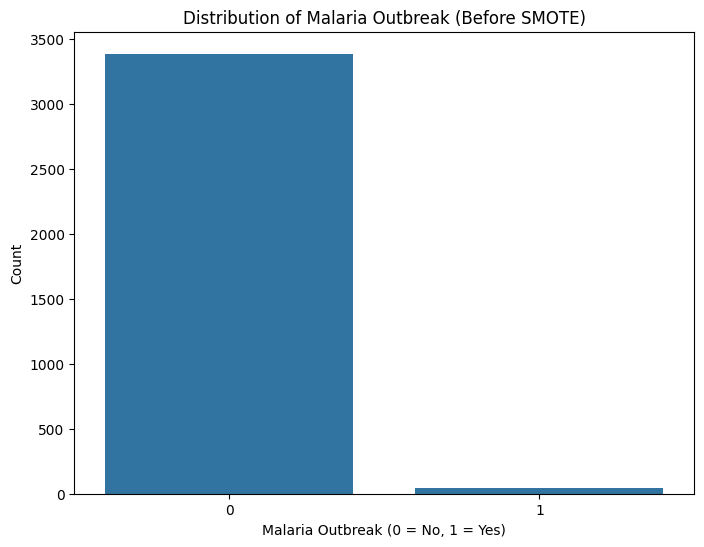

Class Distribution:
malaria_outbreak
0    3386
1      46
Name: count, dtype: int64


In [7]:
# Plot outbreak distribution
plt.figure(figsize=(8, 6))
sns.countplot(x='malaria_outbreak', data=patient)
plt.title('Distribution of Malaria Outbreak (Before SMOTE)')
plt.xlabel('Malaria Outbreak (0 = No, 1 = Yes)')
plt.ylabel('Count')
plt.show()

# Print class distribution
print("Class Distribution:")
print(patient['malaria_outbreak'].value_counts())

In [8]:
# Merge patient and meteorological data
combined = pd.merge(patient, meteorological, 
                   on=['District', 'Year', 'Week'], 
                   how='left')

# Merge with control measures
combined = pd.merge(combined, controls, 
                   on=['District', 'Year', 'Week'], 
                   how='left')

# Create Date column from Year and Week
combined['Date'] = pd.to_datetime(combined['Year'].astype(str) + '-' + 
                                 combined['Week'].astype(str) + '-1', 
                                 format='%Y-%W-%w')

# Display final dataset info
print("\nFinal Combined Dataset:")
print(combined.info())


Final Combined Dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3432 entries, 0 to 3431
Data columns (total 41 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   District             3432 non-null   object        
 1   Year                 3432 non-null   int64         
 2   Week                 3432 non-null   int64         
 3   true_malaria_cases   3432 non-null   int64         
 4   prop_male            3432 non-null   float64       
 5   prop_female          3432 non-null   float64       
 6   prop_<5_age          3432 non-null   float64       
 7   prop_5_14_age        3432 non-null   float64       
 8   prop_15_29_age       3432 non-null   float64       
 9   prop_30_44_age       3432 non-null   float64       
 10  prop_45+_age         3432 non-null   float64       
 11  is_index             3432 non-null   int64         
 12  is_additional_index  3432 non-null   int64         
 13  is_other

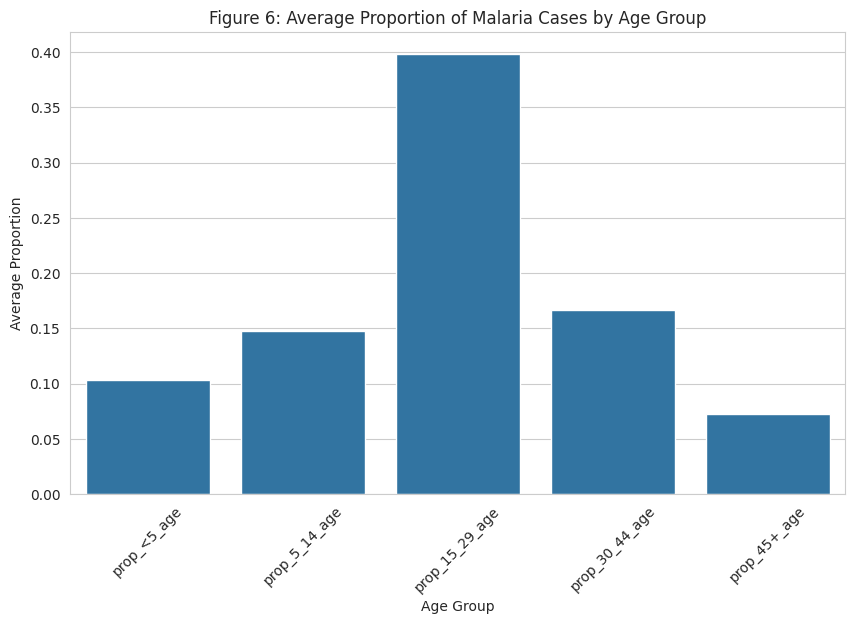

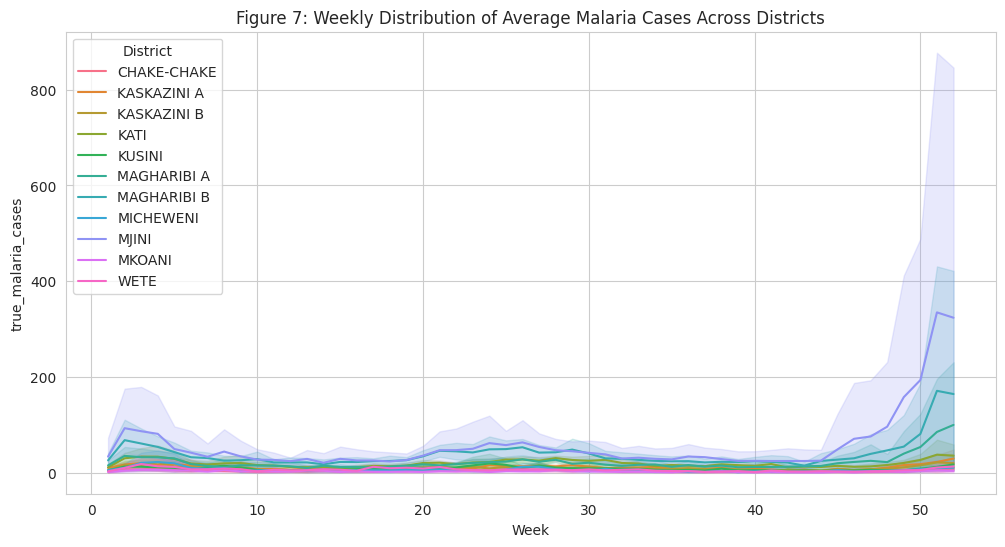

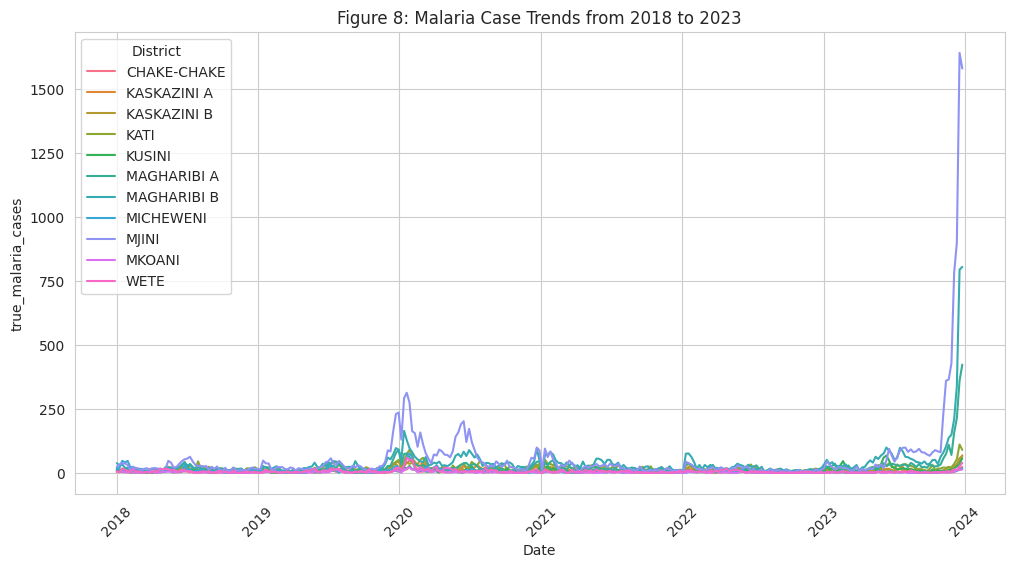

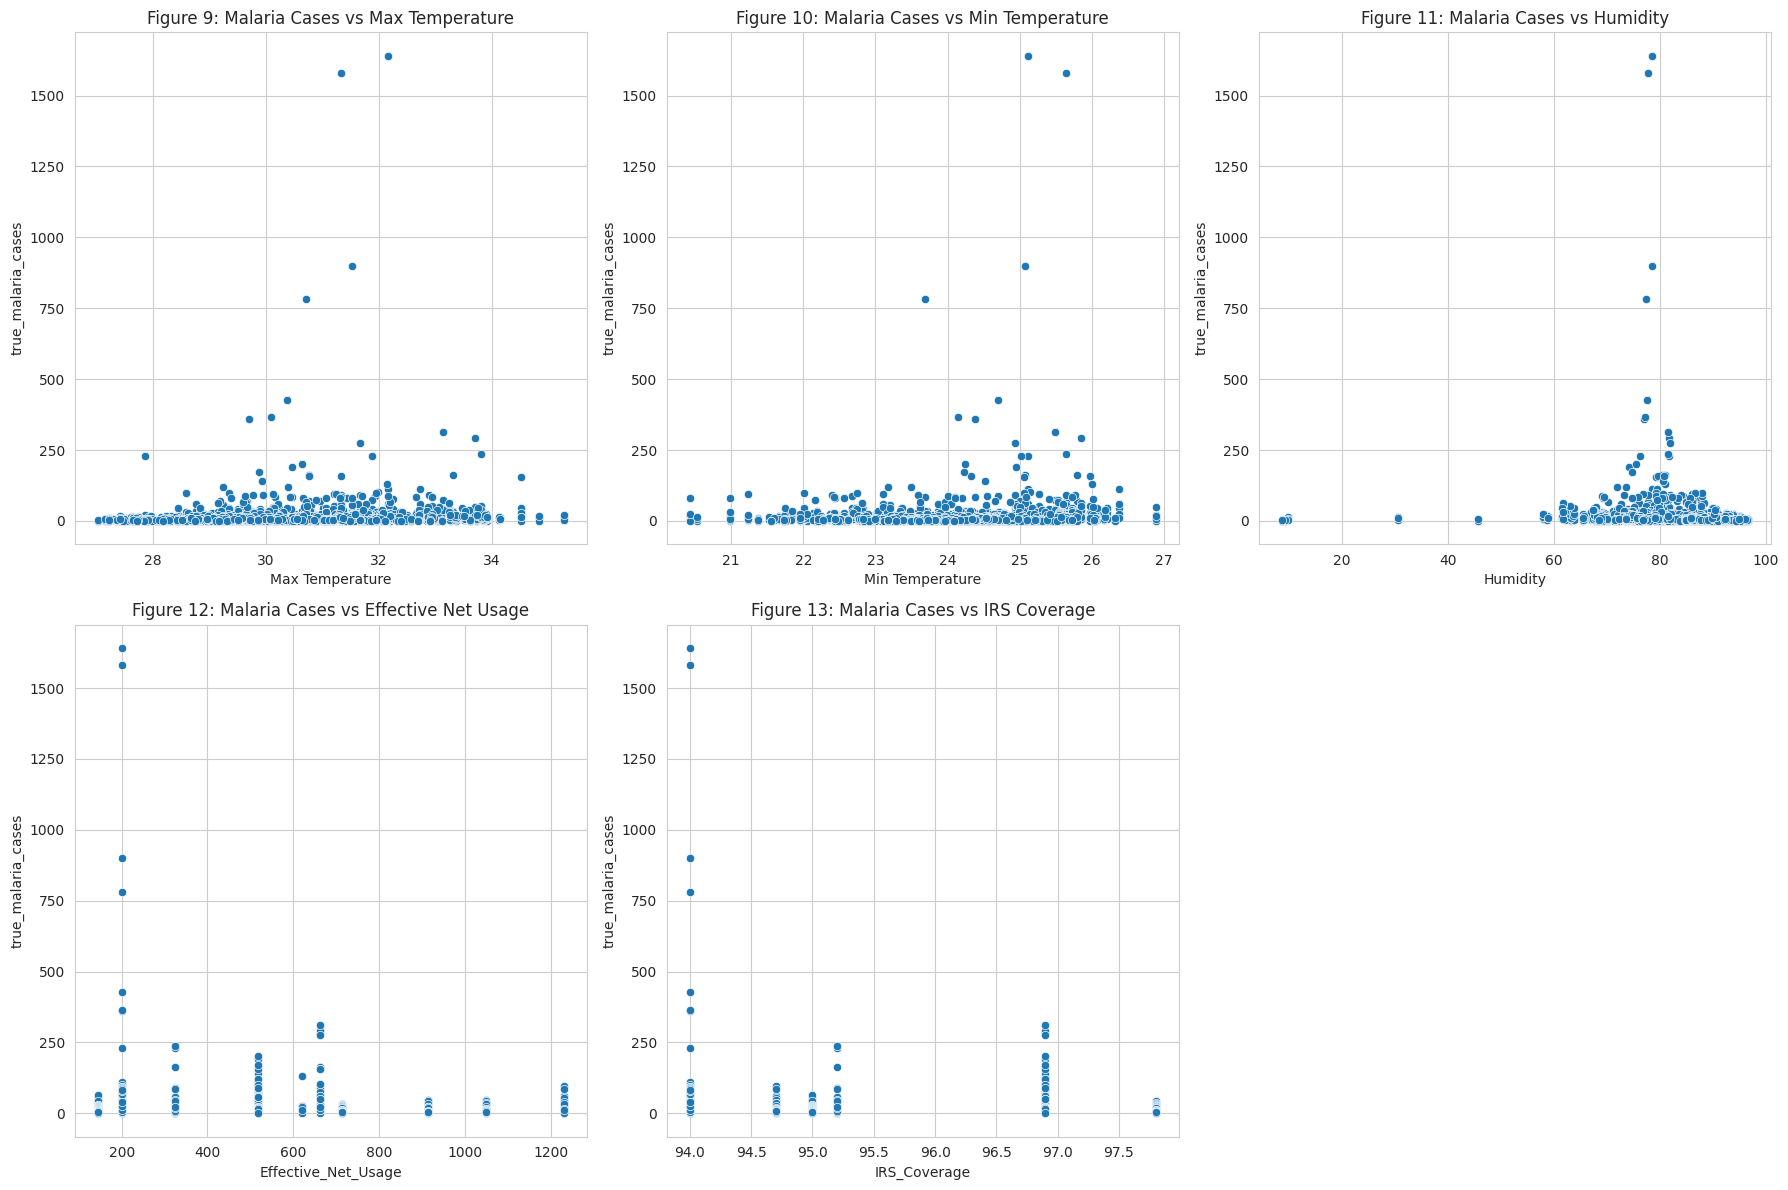

In [9]:
# Set style for plots
sns.set_style("whitegrid")

# Figure 6: Age group vs malaria cases
age_cols = ['prop_<5_age', 'prop_5_14_age', 'prop_15_29_age', 
            'prop_30_44_age', 'prop_45+_age']
age_data = combined[age_cols].mean().reset_index()
age_data.columns = ['Age Group', 'Average Proportion']

plt.figure(figsize=(10, 6))
sns.barplot(x='Age Group', y='Average Proportion', data=age_data)
plt.title('Figure 6: Average Proportion of Malaria Cases by Age Group')
plt.xticks(rotation=45)
plt.show()

# Figure 7: Weekly distribution of average malaria cases across districts
plt.figure(figsize=(12, 6))
sns.lineplot(x='Week', y='true_malaria_cases', hue='District', data=combined)
plt.title('Figure 7: Weekly Distribution of Average Malaria Cases Across Districts')
plt.show()

# Figure 8: Malaria case trends from 2018 to 2023
plt.figure(figsize=(12, 6))
sns.lineplot(x='Date', y='true_malaria_cases', hue='District', data=combined)
plt.title('Figure 8: Malaria Case Trends from 2018 to 2023')
plt.xticks(rotation=45)
plt.show()

# Figure 9-13: Relationship between cases and environmental factors
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# Figure 9: Cases vs Max Temperature
sns.scatterplot(x='Max Temperature', y='true_malaria_cases', data=combined, ax=axes[0, 0])
axes[0, 0].set_title('Figure 9: Malaria Cases vs Max Temperature')

# Figure 10: Cases vs Min Temperature
sns.scatterplot(x='Min Temperature', y='true_malaria_cases', data=combined, ax=axes[0, 1])
axes[0, 1].set_title('Figure 10: Malaria Cases vs Min Temperature')

# Figure 11: Cases vs Humidity
sns.scatterplot(x='Humidity', y='true_malaria_cases', data=combined, ax=axes[0, 2])
axes[0, 2].set_title('Figure 11: Malaria Cases vs Humidity')

# Figure 12: Cases vs Effective Net Usage
sns.scatterplot(x='Effective_Net_Usage', y='true_malaria_cases', data=combined, ax=axes[1, 0])
axes[1, 0].set_title('Figure 12: Malaria Cases vs Effective Net Usage')

# Figure 13: Cases vs IRS Coverage
sns.scatterplot(x='IRS_Coverage', y='true_malaria_cases', data=combined, ax=axes[1, 1])
axes[1, 1].set_title('Figure 13: Malaria Cases vs IRS Coverage')

# Remove empty subplot
fig.delaxes(axes[1, 2])

plt.tight_layout()
plt.show()

In [10]:
# Select relevant features for modeling
features = [
    'prop_male', 'prop_female', 'prop_<5_age', 'prop_5_14_age', 
    'prop_15_29_age', 'prop_30_44_age', 'prop_45+_age',
    'average_latitude', 'average_longitude', 'is_index', 
    'is_additional_index', 'is_other_member', 'is_private', 'is_public',
    'occ_student', 'occ_health_worker', 'occ_police_officer', 
    'occ_watchman', 'occ_farmer', 'occ_fisherman', 'occ_unemployed',
    'occ_housewife', 'occ_business_owner', 'Humidity', 'Rainfall',
    'Min Temperature', 'Max Temperature', 'Temperature_Range',
    'Effective_Net_Usage', 'IRS_Coverage', 'Month'
]

target = 'malaria_outbreak'

# Create feature and target datasets
X = combined[features]
y = combined[target]

# Handle remaining missing values
X = X.fillna(X.mean())

# Standardize numerical features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

In [11]:
# Since it's time series data, we'll split by date
split_date = '2022-01-01'
train = combined[combined['Date'] < split_date]
test = combined[combined['Date'] >= split_date]

X_train = train[features].fillna(train[features].mean())
X_test = test[features].fillna(test[features].mean())

y_train = train[target]
y_test = test[target]

# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

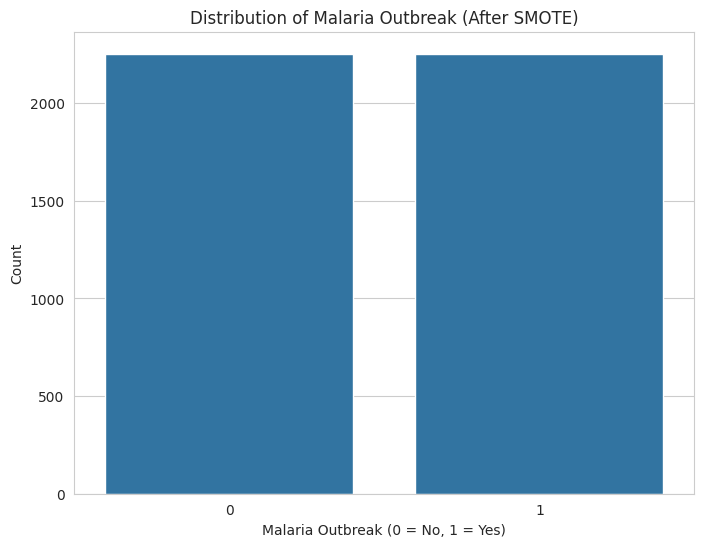

Class Distribution After SMOTE:
malaria_outbreak
0    2253
1    2253
Name: count, dtype: int64


In [12]:
# Apply SMOTE only to the training set
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train_scaled, y_train)

# Visualize class distribution after SMOTE
plt.figure(figsize=(8, 6))
sns.countplot(x=y_train_res)
plt.title('Distribution of Malaria Outbreak (After SMOTE)')
plt.xlabel('Malaria Outbreak (0 = No, 1 = Yes)')
plt.ylabel('Count')
plt.show()

print("Class Distribution After SMOTE:")
print(pd.Series(y_train_res).value_counts())

Skewness Analysis:
               Feature   Skewness
0   true_malaria_cases  19.382361
1             Rainfall   3.344703
2         IRS_Coverage   0.563958
3  Effective_Net_Usage   0.513517
4      Max Temperature   0.086989
5      Min Temperature  -0.508116
6             Humidity  -2.343998


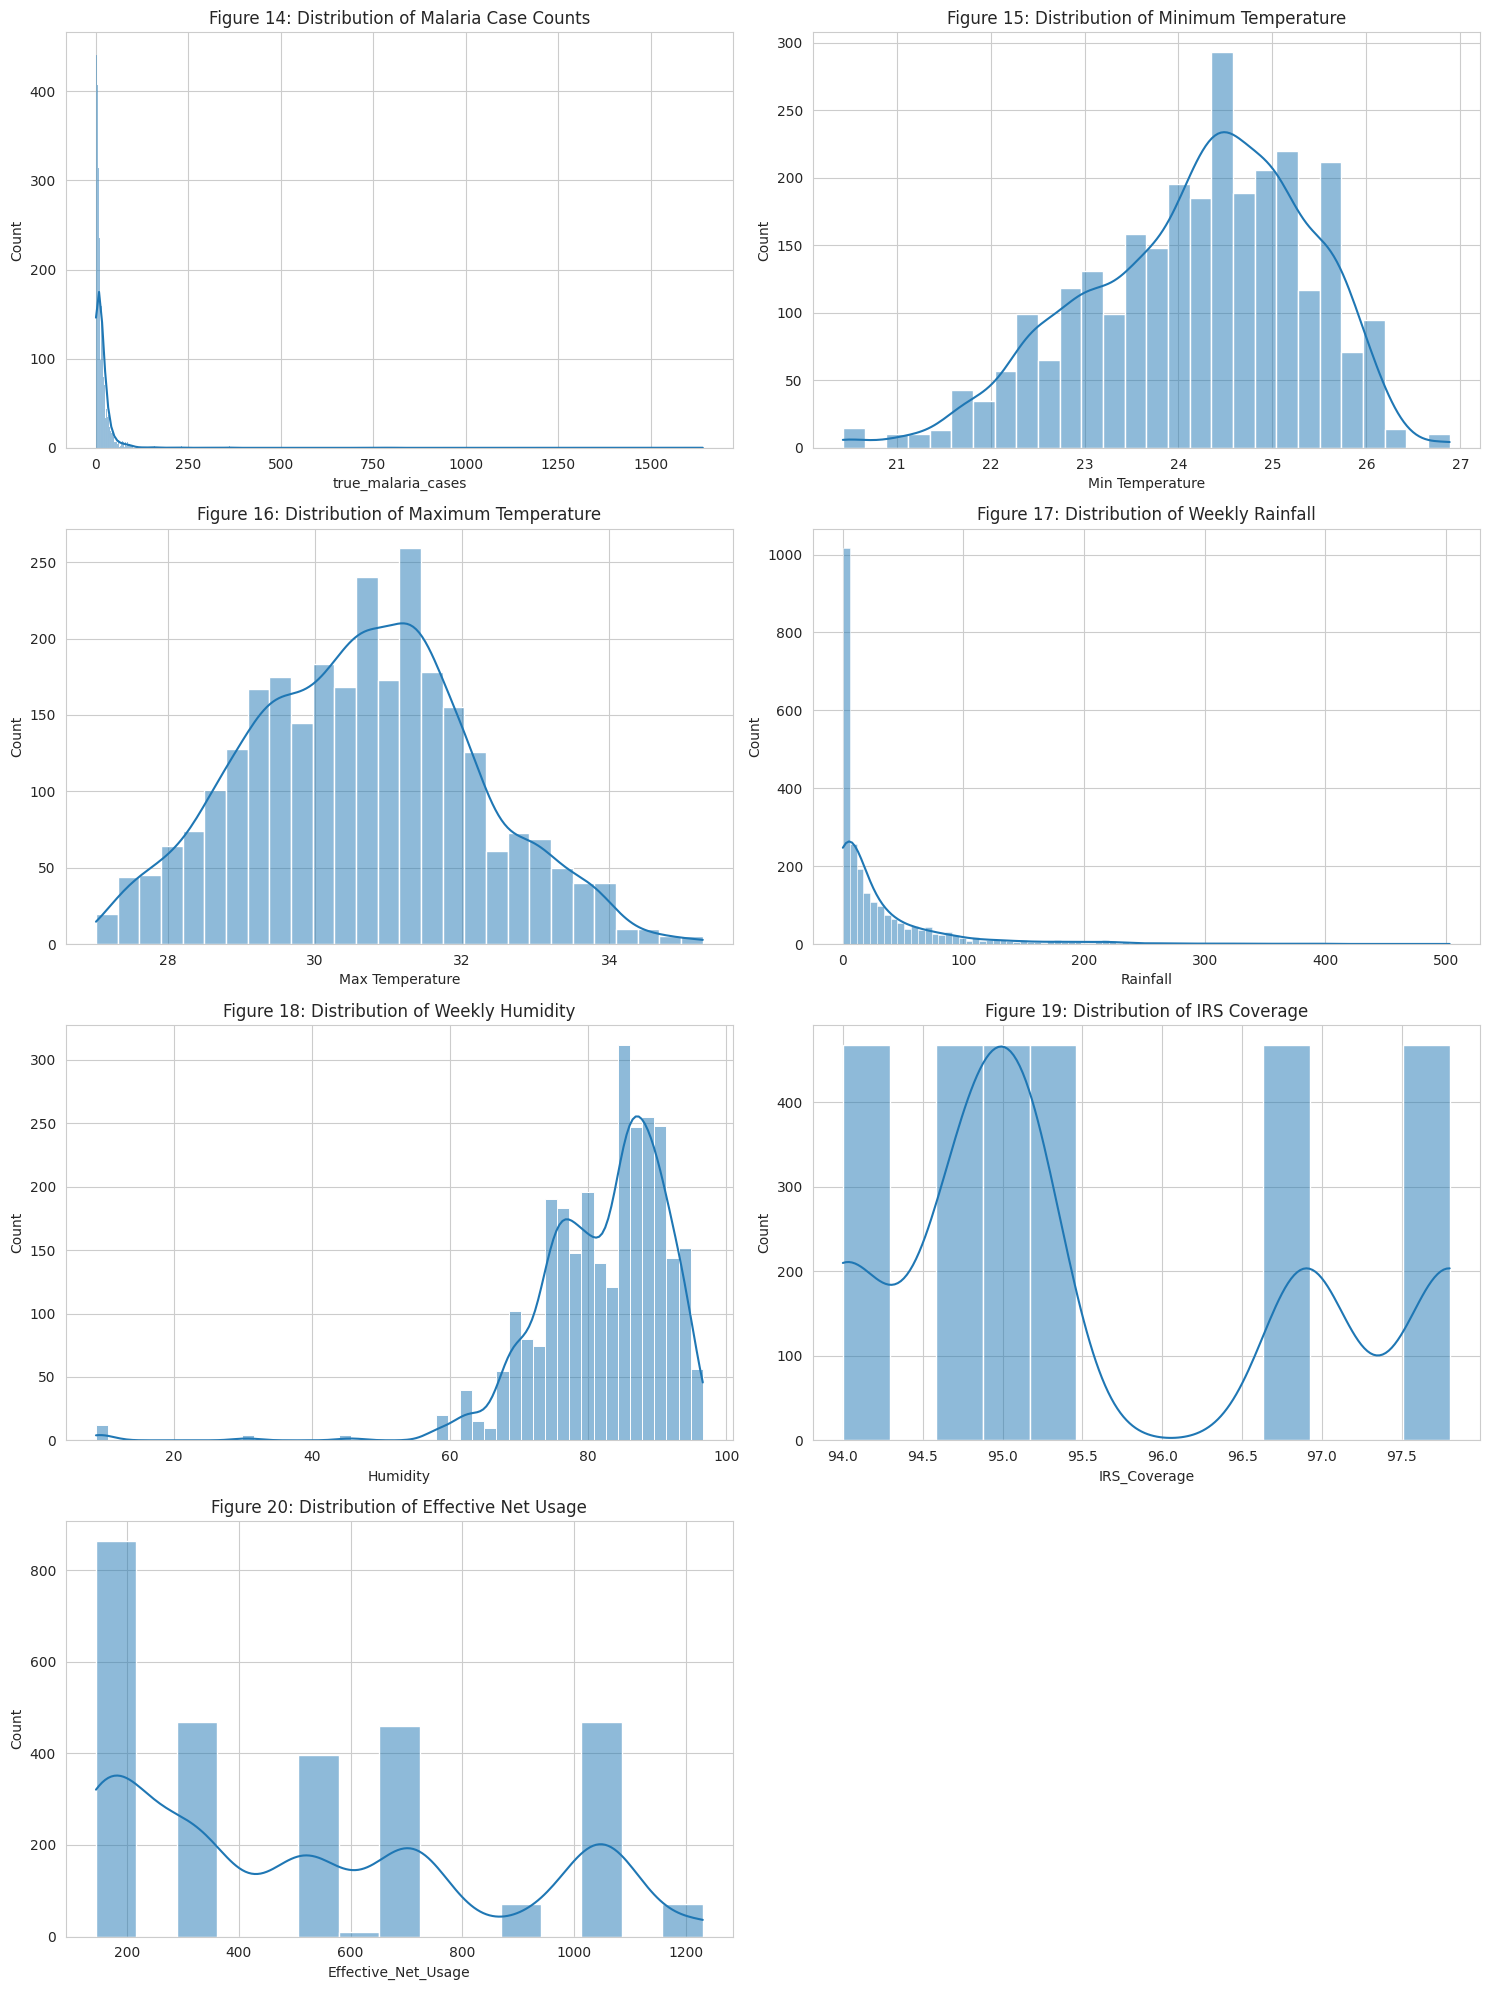

Applied transformation to true_malaria_cases (skewness: 19.38)
Applied transformation to Humidity (skewness: -2.34)
Applied transformation to Rainfall (skewness: 3.34)


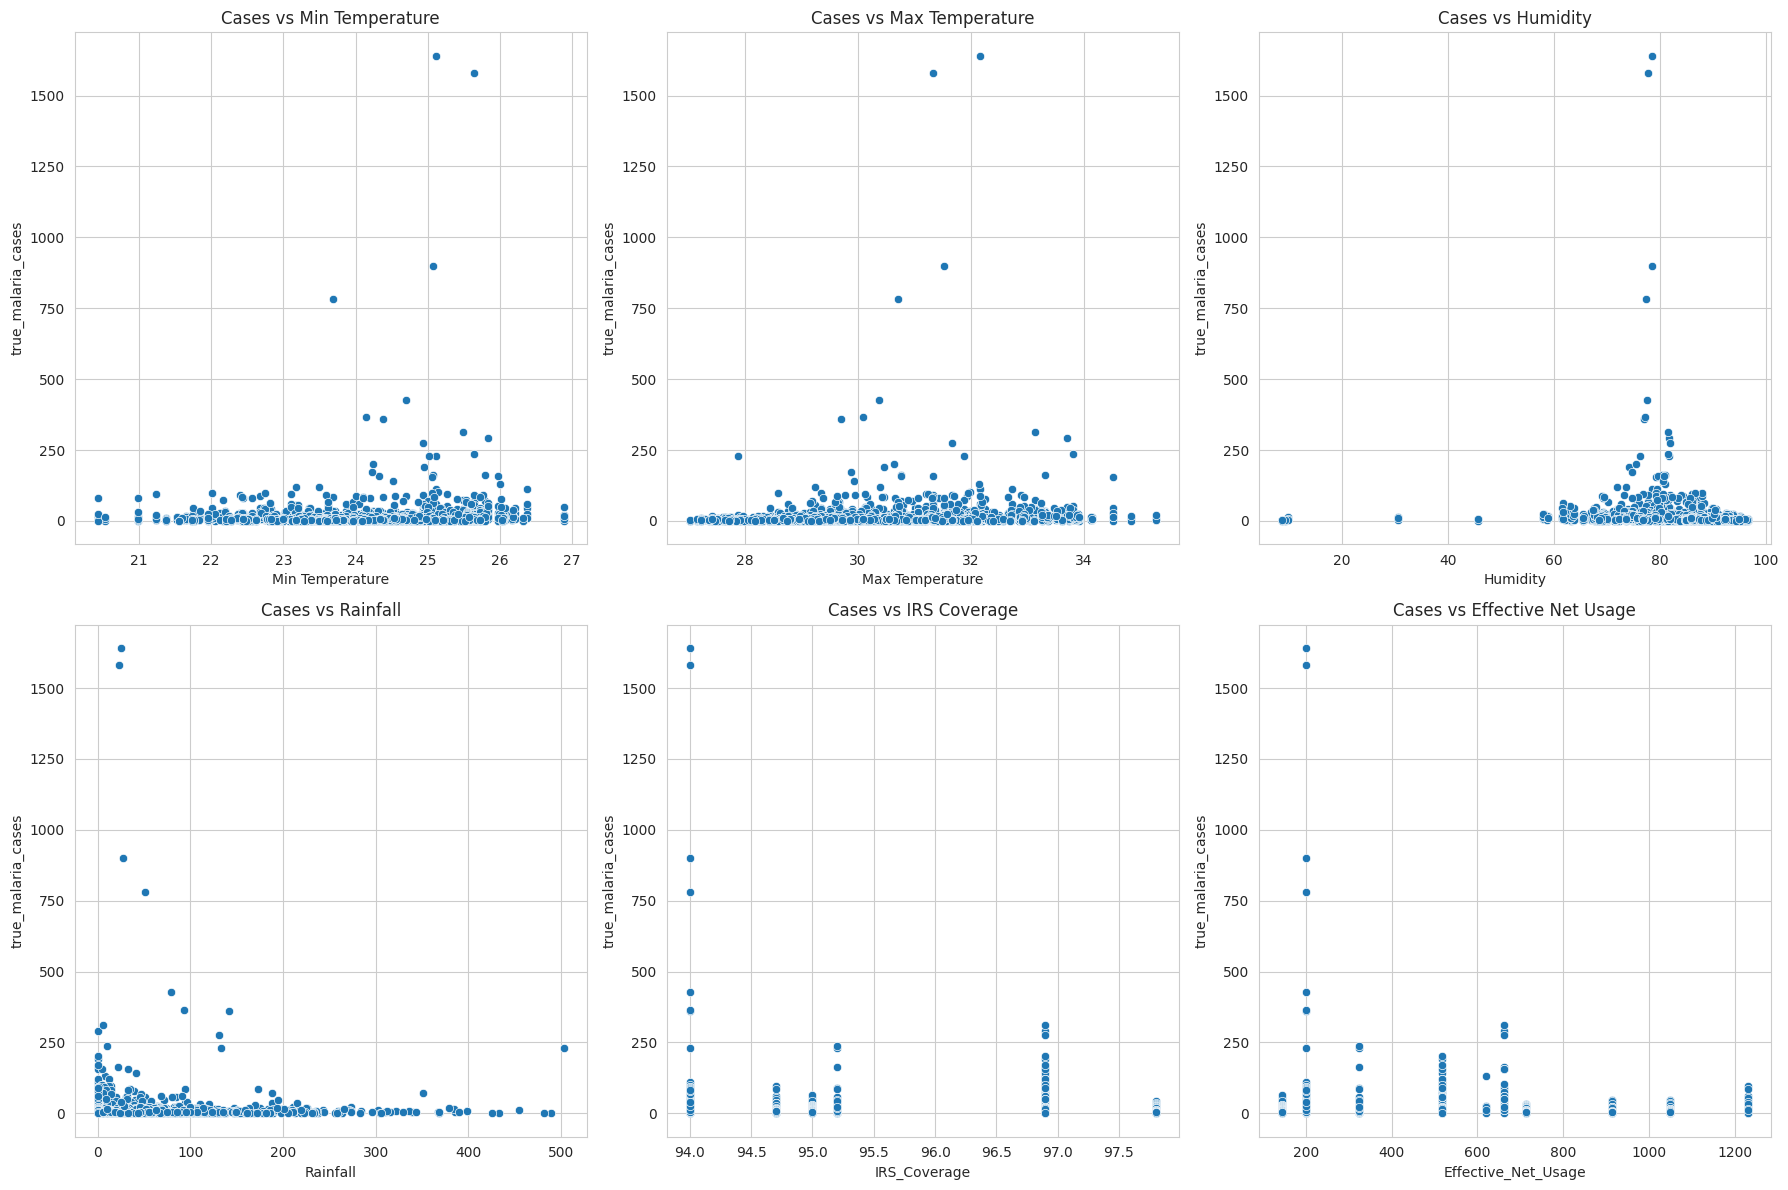

In [18]:
# Calculate skewness for numerical features
numerical_features = [
    'true_malaria_cases', 'Humidity', 'Rainfall', 
    'Min Temperature', 'Max Temperature', 
    'Effective_Net_Usage', 'IRS_Coverage'
]

skewness = combined[numerical_features].skew().sort_values(ascending=False)
skewness_df = pd.DataFrame({'Feature': skewness.index, 'Skewness': skewness.values})

print("Skewness Analysis:")
print(skewness_df)

# Plot distributions for skewed features
plt.figure(figsize=(15, 20))

# Figure 14: Distribution of malaria case counts
plt.subplot(4, 2, 1)
sns.histplot(combined['true_malaria_cases'], kde=True)
plt.title('Figure 14: Distribution of Malaria Case Counts')

# Figure 15: Distribution of minimum temperature
plt.subplot(4, 2, 2)
sns.histplot(combined['Min Temperature'], kde=True)
plt.title('Figure 15: Distribution of Minimum Temperature')

# Figure 16: Distribution of maximum temperature
plt.subplot(4, 2, 3)
sns.histplot(combined['Max Temperature'], kde=True)
plt.title('Figure 16: Distribution of Maximum Temperature')

# Figure 17: Distribution of weekly rainfall
plt.subplot(4, 2, 4)
sns.histplot(combined['Rainfall'], kde=True)
plt.title('Figure 17: Distribution of Weekly Rainfall')

# Figure 18: Distribution of weekly humidity
plt.subplot(4, 2, 5)
sns.histplot(combined['Humidity'], kde=True)
plt.title('Figure 18: Distribution of Weekly Humidity')

# Figure 19: Distribution of IRS coverage
plt.subplot(4, 2, 6)
sns.histplot(combined['IRS_Coverage'], kde=True)
plt.title('Figure 19: Distribution of IRS Coverage')

# Figure 20: Distribution of effective net coverage
plt.subplot(4, 2, 7)
sns.histplot(combined['Effective_Net_Usage'], kde=True)
plt.title('Figure 20: Distribution of Effective Net Usage')

plt.tight_layout()
plt.show()

# Apply transformations to highly skewed features
from sklearn.preprocessing import PowerTransformer

# Apply log transformation to highly skewed features (|skewness| > 1)
for feature in numerical_features:
    if abs(skewness[feature]) > 1:
        pt = PowerTransformer(method='yeo-johnson', standardize=False)
        combined[f'{feature}_transformed'] = pt.fit_transform(combined[[feature]])
        print(f"Applied transformation to {feature} (skewness: {skewness[feature]:.2f})")

# Figure 21: Scatter plots of cases vs environmental factors
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

sns.scatterplot(x='Min Temperature', y='true_malaria_cases', data=combined, ax=axes[0, 0])
axes[0, 0].set_title('Cases vs Min Temperature')

sns.scatterplot(x='Max Temperature', y='true_malaria_cases', data=combined, ax=axes[0, 1])
axes[0, 1].set_title('Cases vs Max Temperature')

sns.scatterplot(x='Humidity', y='true_malaria_cases', data=combined, ax=axes[0, 2])
axes[0, 2].set_title('Cases vs Humidity')

sns.scatterplot(x='Rainfall', y='true_malaria_cases', data=combined, ax=axes[1, 0])
axes[1, 0].set_title('Cases vs Rainfall')

sns.scatterplot(x='IRS_Coverage', y='true_malaria_cases', data=combined, ax=axes[1, 1])
axes[1, 1].set_title('Cases vs IRS Coverage')

sns.scatterplot(x='Effective_Net_Usage', y='true_malaria_cases', data=combined, ax=axes[1, 2])
axes[1, 2].set_title('Cases vs Effective Net Usage')

plt.tight_layout()
plt.show()

In [19]:
# Create additional time-based features
combined['month_sin'] = np.sin(2 * np.pi * combined['Month']/12)
combined['month_cos'] = np.cos(2 * np.pi * combined['Month']/12)

# Create rolling statistics
def create_rolling_features(df, group_col='District', value_col='true_malaria_cases', windows=[4, 8, 12]):
    df = df.sort_values([group_col, 'Year', 'Week'])
    for window in windows:
        df[f'{value_col}_rolling_mean_{window}'] = df.groupby(group_col)[value_col].transform(
            lambda x: x.rolling(window=window, min_periods=1).mean())
        df[f'{value_col}_rolling_std_{window}'] = df.groupby(group_col)[value_col].transform(
            lambda x: x.rolling(window=window, min_periods=1).std())
    return df

combined = create_rolling_features(combined)

# Create lag features (already done in previous step, but adding more)
combined = create_lag_features(combined, numerical_features, lags=[1, 2, 3, 4])

# Create district dummy variables
combined = pd.get_dummies(combined, columns=['District'], prefix='district')

print("\nAdditional Features Created:")
print(combined.filter(regex='rolling|lag|district|month_').columns)


Additional Features Created:
Index(['month_sin', 'month_cos', 'true_malaria_cases_rolling_mean_4',
       'true_malaria_cases_rolling_std_4', 'true_malaria_cases_rolling_mean_8',
       'true_malaria_cases_rolling_std_8',
       'true_malaria_cases_rolling_mean_12',
       'true_malaria_cases_rolling_std_12', 'true_malaria_cases_lag_1',
       'Humidity_lag_1', 'Rainfall_lag_1', 'Min Temperature_lag_1',
       'Max Temperature_lag_1', 'Effective_Net_Usage_lag_1',
       'IRS_Coverage_lag_1', 'true_malaria_cases_lag_2', 'Humidity_lag_2',
       'Rainfall_lag_2', 'Min Temperature_lag_2', 'Max Temperature_lag_2',
       'Effective_Net_Usage_lag_2', 'IRS_Coverage_lag_2',
       'true_malaria_cases_lag_3', 'Humidity_lag_3', 'Rainfall_lag_3',
       'Min Temperature_lag_3', 'Max Temperature_lag_3',
       'Effective_Net_Usage_lag_3', 'IRS_Coverage_lag_3',
       'true_malaria_cases_lag_4', 'Humidity_lag_4', 'Rainfall_lag_4',
       'Min Temperature_lag_4', 'Max Temperature_lag_4',
       'E

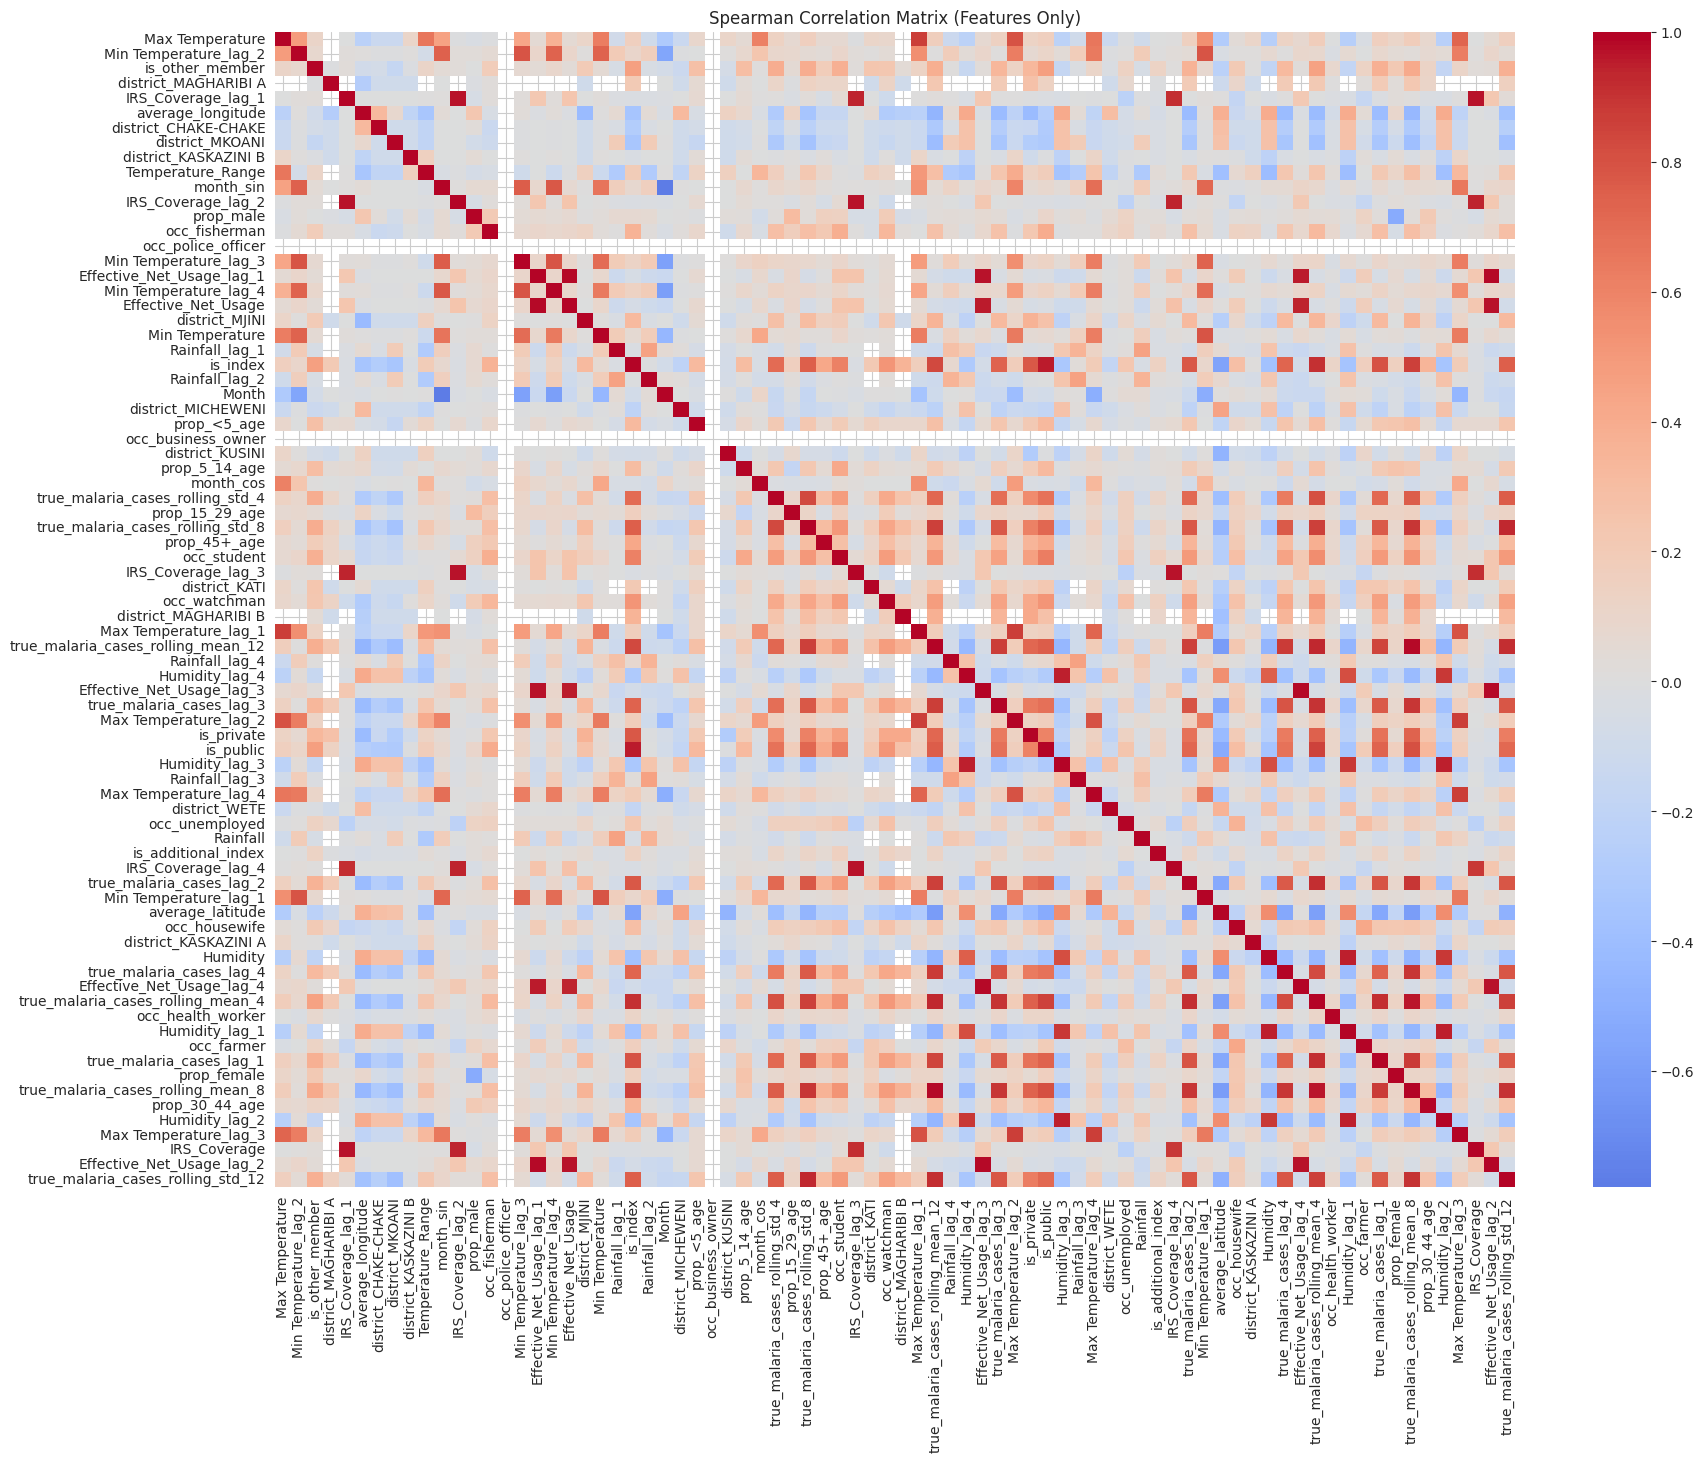

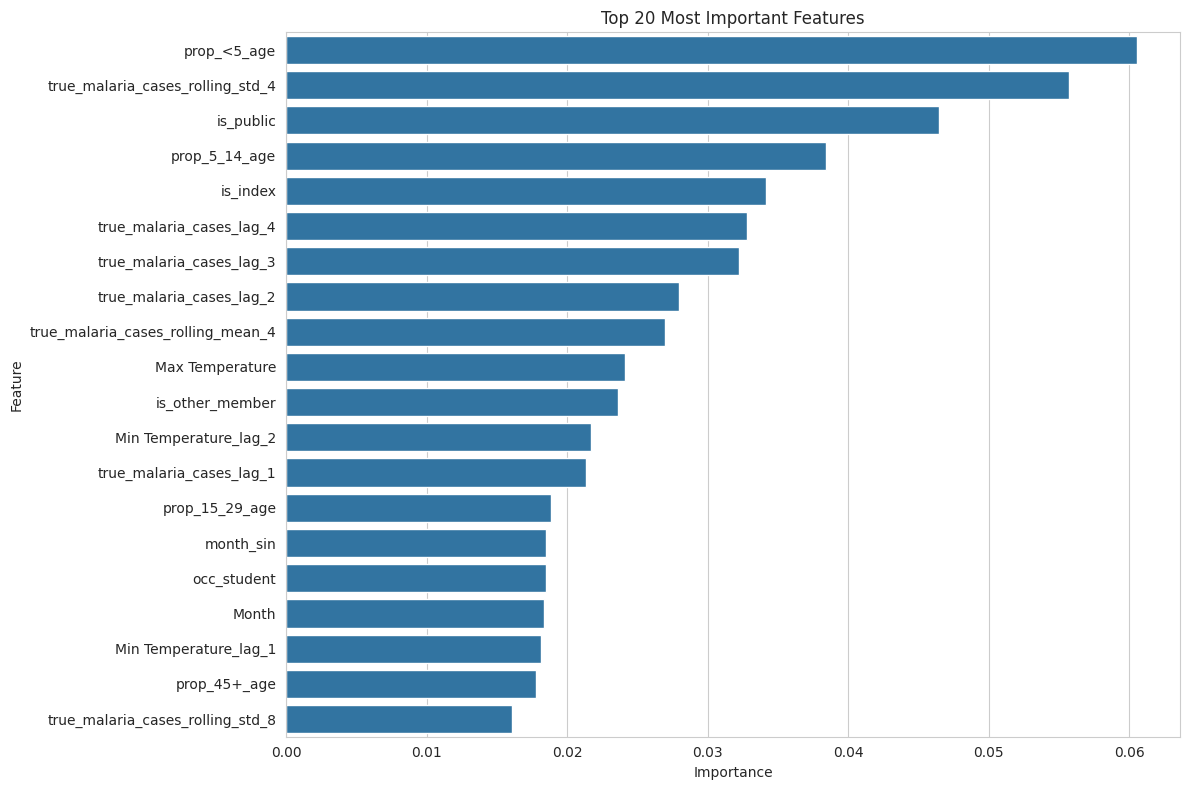


Selected 9 features with importance > 0.025:
['prop_<5_age', 'true_malaria_cases_rolling_std_4', 'is_public', 'prop_5_14_age', 'is_index', 'true_malaria_cases_lag_4', 'true_malaria_cases_lag_3', 'true_malaria_cases_lag_2', 'true_malaria_cases_rolling_mean_4']


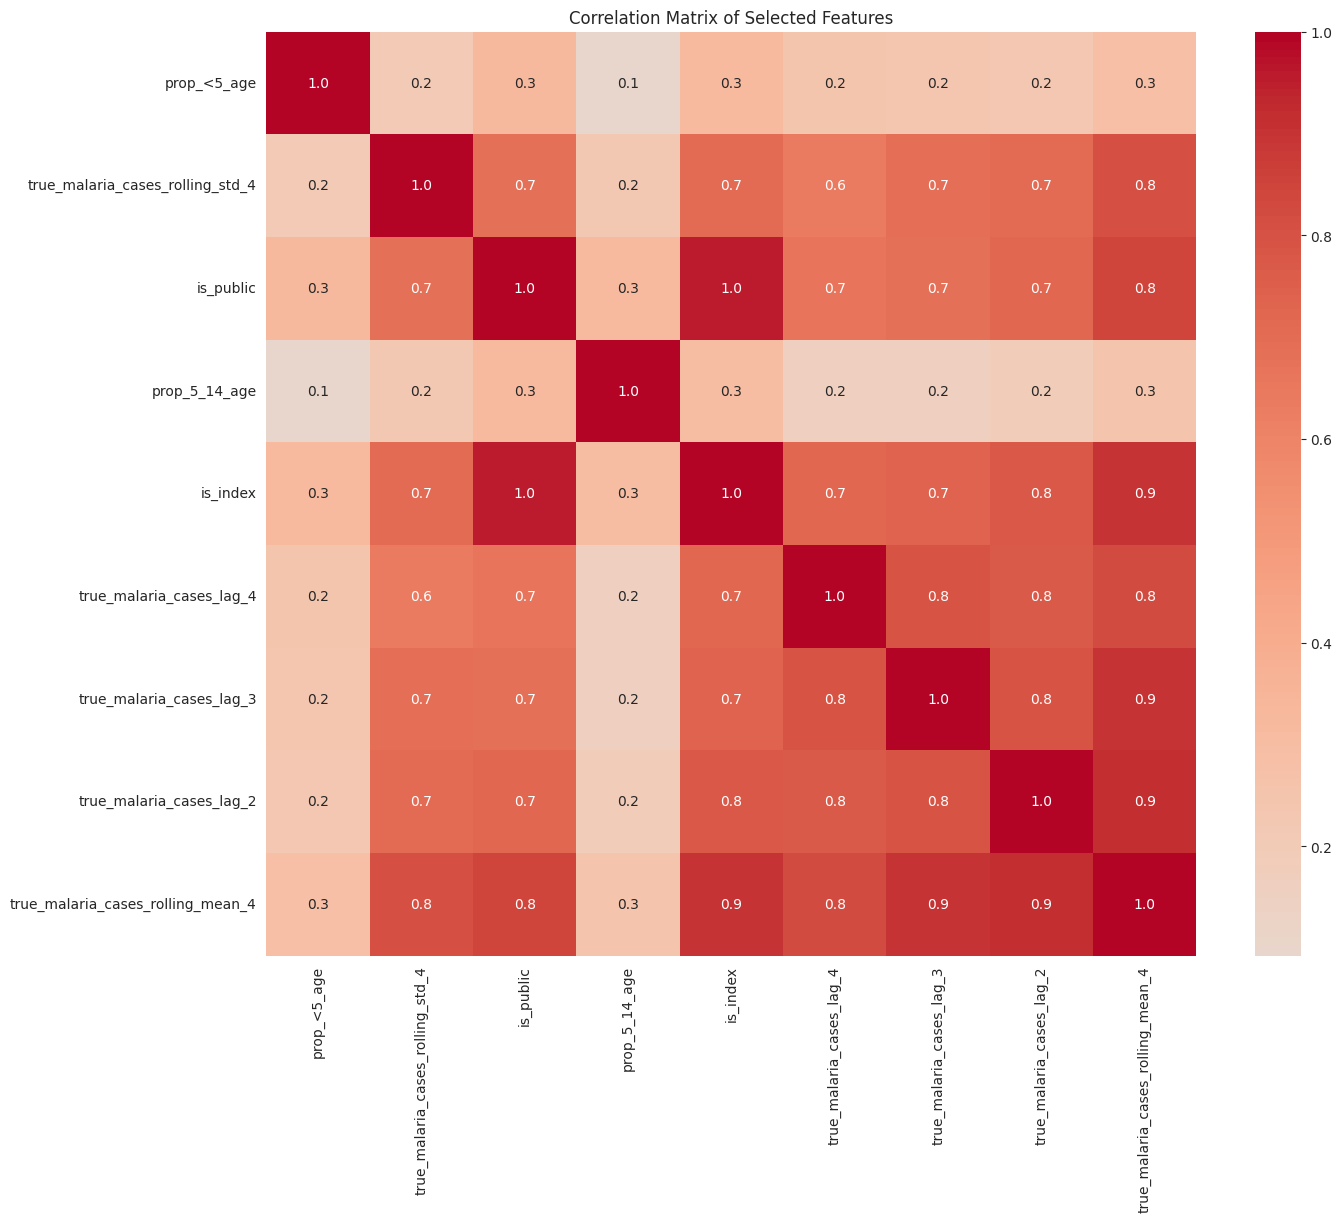

In [20]:
# Prepare final feature set
all_features = [
    'prop_male', 'prop_female', 'prop_<5_age', 'prop_5_14_age', 
    'prop_15_29_age', 'prop_30_44_age', 'prop_45+_age',
    'average_latitude', 'average_longitude', 'is_index', 
    'is_additional_index', 'is_other_member', 'is_private', 'is_public',
    'occ_student', 'occ_health_worker', 'occ_police_officer', 
    'occ_watchman', 'occ_farmer', 'occ_fisherman', 'occ_unemployed',
    'occ_housewife', 'occ_business_owner', 'Humidity', 'Rainfall',
    'Min Temperature', 'Max Temperature', 'Temperature_Range',
    'Effective_Net_Usage', 'IRS_Coverage', 'Month',
    'month_sin', 'month_cos'
] + list(combined.filter(regex='rolling|lag|district').columns)

# Remove any duplicate features
all_features = list(set(all_features))

# Create correlation matrix (Spearman)
corr_matrix = combined[all_features].corr(method='spearman')

# Plot correlation matrix
plt.figure(figsize=(20, 15))
sns.heatmap(corr_matrix, cmap='coolwarm', center=0)
plt.title('Spearman Correlation Matrix (Features Only)')
plt.show()

# Feature importance using Random Forest
from sklearn.ensemble import RandomForestClassifier

# Prepare data for feature importance
X_all = combined[all_features].fillna(combined[all_features].mean())
y_all = combined['malaria_outbreak']

# Train RF for feature importance
rf_feature_selector = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
rf_feature_selector.fit(X_all, y_all)

# Get feature importances
importances = rf_feature_selector.feature_importances_
feature_importance_df = pd.DataFrame({'Feature': all_features, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values('Importance', ascending=False)

# Plot feature importance
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(20))
plt.title('Top 20 Most Important Features')
plt.tight_layout()
plt.show()

# Select features above cutoff (0.025)
selected_features = feature_importance_df[feature_importance_df['Importance'] > 0.025]['Feature'].tolist()
print(f"\nSelected {len(selected_features)} features with importance > 0.025:")
print(selected_features)

# Check correlation among selected features
selected_corr = combined[selected_features].corr(method='spearman')

# Plot correlation matrix for selected features
plt.figure(figsize=(15, 12))
sns.heatmap(selected_corr, cmap='coolwarm', center=0, annot=True, fmt='.1f')
plt.title('Correlation Matrix of Selected Features')
plt.show()

# Apply PCA if needed (if many correlated features)
from sklearn.decomposition import PCA

if len(selected_features) > 20:  # Arbitrary threshold for PCA
    print("Applying PCA due to large number of selected features")
    
    # Standardize features
    X_selected = combined[selected_features].fillna(combined[selected_features].mean())
    scaler_pca = StandardScaler()
    X_selected_scaled = scaler_pca.fit_transform(X_selected)
    
    # Fit PCA
    pca = PCA().fit(X_selected_scaled)
    
    # Plot explained variance
    plt.figure(figsize=(10, 6))
    plt.plot(np.cumsum(pca.explained_variance_ratio_))
    plt.xlabel('Number of Components')
    plt.ylabel('Cumulative Explained Variance')
    plt.title('PCA Explained Variance')
    plt.grid()
    plt.show()
    
    # Get number of components to explain 95% variance
    n_components = np.argmax(np.cumsum(pca.explained_variance_ratio_) >= 0.95) + 1
    print(f"Number of components explaining 95% variance: {n_components}")
    
    # Apply PCA transformation
    pca = PCA(n_components=n_components)
    X_pca = pca.fit_transform(X_selected_scaled)
    
    # Create PCA feature names
    pca_features = [f'PC_{i+1}' for i in range(n_components)]
    
    # Update selected features to PCA components
    selected_features = pca_features
    X_selected = pd.DataFrame(X_pca, columns=pca_features)
else:
    X_selected = combined[selected_features].fillna(combined[selected_features].mean())


Training SVM...
SVM Results:
Accuracy: 0.9266
ROC AUC: 0.9475
F1 Score: 0.1923
Confusion Matrix:
[[1050   83]
 [   1   10]]
Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.93      0.96      1133
           1       0.11      0.91      0.19        11

    accuracy                           0.93      1144
   macro avg       0.55      0.92      0.58      1144
weighted avg       0.99      0.93      0.95      1144


Training Random Forest...
Random Forest Results:
Accuracy: 0.9808
ROC AUC: 0.9216
F1 Score: 0.1538
Confusion Matrix:
[[1120   13]
 [   9    2]]
Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1133
           1       0.13      0.18      0.15        11

    accuracy                           0.98      1144
   macro avg       0.56      0.59      0.57      1144
weighted avg       0.98      0.98      0.98      1144


Training XGBoost...
XGBoost R

<Figure size 1000x600 with 0 Axes>

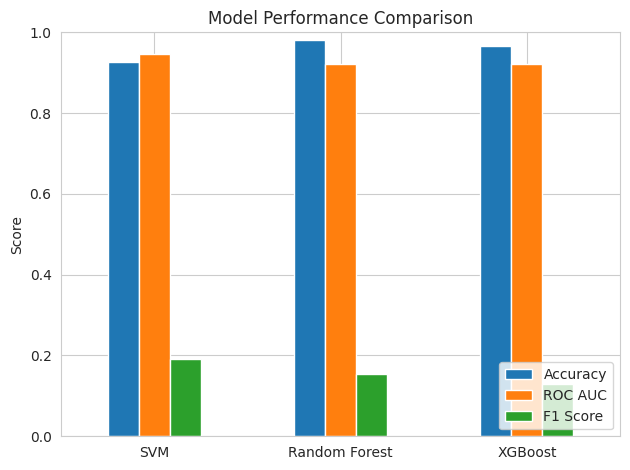

In [21]:
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import roc_auc_score, f1_score

# Prepare final datasets with selected features
X_final = X_selected
y_final = combined['malaria_outbreak']

# Time-aware train-test split
split_date = '2022-01-01'
train_mask = combined['Date'] < split_date
test_mask = combined['Date'] >= split_date

X_train, X_test = X_final[train_mask], X_final[test_mask]
y_train, y_test = y_final[train_mask], y_final[test_mask]

# Apply SMOTE only to training data
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

# Scale features
scaler_final = StandardScaler()
X_train_scaled = scaler_final.fit_transform(X_train_res)
X_test_scaled = scaler_final.transform(X_test)

# Initialize models
models = {
    'SVM': SVC(kernel='rbf', probability=True, random_state=42, class_weight='balanced'),
    'Random Forest': RandomForestClassifier(random_state=42, class_weight='balanced'),
    'XGBoost': XGBClassifier(random_state=42, scale_pos_weight=len(y_train[y_train==0])/len(y_train[y_train==1]))
}

# Train and evaluate models
results = {}
for name, model in models.items():
    print(f"\nTraining {name}...")
    model.fit(X_train_scaled, y_train_res)
    
    # Predictions
    y_pred = model.predict(X_test_scaled)
    y_prob = model.predict_proba(X_test_scaled)[:, 1]
    
    # Evaluation metrics
    accuracy = accuracy_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_prob)
    f1 = f1_score(y_test, y_pred)
    
    # Store results
    results[name] = {
        'Accuracy': accuracy,
        'ROC AUC': roc_auc,
        'F1 Score': f1,
        'Confusion Matrix': confusion_matrix(y_test, y_pred),
        'Classification Report': classification_report(y_test, y_pred)
    }
    
    print(f"{name} Results:")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"ROC AUC: {roc_auc:.4f}")
    print(f"F1 Score: {f1:.4f}")
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))
    print("Classification Report:")
    print(classification_report(y_test, y_pred))

# Compare model performance
results_df = pd.DataFrame.from_dict({k: [v['Accuracy'], v['ROC AUC'], v['F1 Score']] 
                                   for k, v in results.items()},
                                  orient='index',
                                  columns=['Accuracy', 'ROC AUC', 'F1 Score'])

print("\nModel Comparison:")
print(results_df.sort_values('F1 Score', ascending=False))

# Plot performance comparison
plt.figure(figsize=(10, 6))
results_df.plot(kind='bar', rot=0)
plt.title('Model Performance Comparison')
plt.ylabel('Score')
plt.ylim(0, 1)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

In [22]:
# Select best model based on F1 score
best_model_name = results_df['F1 Score'].idxmax()
best_model = models[best_model_name]

print(f"\nBest Model: {best_model_name}")
print(f"F1 Score: {results[best_model_name]['F1 Score']:.4f}")

# Feature importance for best model (if available)
if hasattr(best_model, 'feature_importances_'):
    if len(selected_features) <= 20:  # Only plot if not using PCA
        importances = best_model.feature_importances_
        indices = np.argsort(importances)[::-1]
        
        plt.figure(figsize=(12, 8))
        plt.title("Best Model Feature Importances")
        plt.bar(range(len(selected_features)), importances[indices], align="center")
        plt.xticks(range(len(selected_features)), np.array(selected_features)[indices], rotation=90)
        plt.xlim([-1, len(selected_features)])
        plt.tight_layout()
        plt.show()

# Save final model and artifacts
import joblib
from datetime import datetime

# Create model version with timestamp
model_version = f"malaria_outbreak_{best_model_name.lower().replace(' ', '_')}_{datetime.now().strftime('%Y%m%d_%H%M')}"

# Save model
joblib.dump(best_model, f'{model_version}.pkl')

# Save scaler
joblib.dump(scaler_final, 'final_scaler.pkl')

# Save selected features
with open('selected_features.txt', 'w') as f:
    f.write('\n'.join(selected_features))

print(f"\nModel saved as {model_version}.pkl")
print("Scaler saved as final_scaler.pkl")
print("Selected features saved as selected_features.txt")


Best Model: SVM
F1 Score: 0.1923

Model saved as malaria_outbreak_svm_20250626_0234.pkl
Scaler saved as final_scaler.pkl
Selected features saved as selected_features.txt


In [24]:
def predict_outbreak_next_week(current_data, model, scaler, selected_features):
    """
    Predict malaria outbreak for next week based on current data.
    
    Args:
        current_data: DataFrame with current week's data (all districts)
        model: Trained model
        scaler: Fitted scaler
        selected_features: List of features used in model
        
    Returns:
        DataFrame with district and outbreak probability for next week
    """
    # Make a copy to avoid modifying original data
    data = current_data.copy()
    
    # Ensure we have all required features
    missing_features = set(selected_features) - set(data.columns)
    if missing_features:
        raise ValueError(f"Missing required features: {missing_features}")
    
    # Select and scale features
    X = data[selected_features].fillna(data[selected_features].mean())
    X_scaled = scaler.transform(X)
    
    # Predict probabilities
    probabilities = model.predict_proba(X_scaled)[:, 1]
    
    # Create result DataFrame
    results = pd.DataFrame({
        'District': data['District'],
        'Outbreak_Probability_Next_Week': probabilities,
        'Predicted_Outbreak': (probabilities >= 0.5).astype(int)  # Using 0.5 as threshold
    })
    
    return results

# Example usage (would use real current data in production)
current_week_data = combined[combined['Date'] == combined['Date'].max()].copy()
predictions = predict_outbreak_next_week(current_week_data, best_model, scaler_final, selected_features)
print(predictions)

KeyError: 'District'

In [13]:
# Initialize and train Random Forest classifier
rf = RandomForestClassifier(random_state=42, class_weight='balanced')
rf.fit(X_train_res, y_train_res)

# Predict on test set
y_pred = rf.predict(X_test_scaled)

# Evaluate model
print("Model Evaluation:")
print(classification_report(y_test, y_pred))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nAccuracy:", accuracy_score(y_test, y_pred))

Model Evaluation:
              precision    recall  f1-score   support

           0       0.99      1.00      1.00      1133
           1       0.00      0.00      0.00        11

    accuracy                           0.99      1144
   macro avg       0.50      0.50      0.50      1144
weighted avg       0.98      0.99      0.99      1144


Confusion Matrix:
[[1133    0]
 [  11    0]]

Accuracy: 0.9903846153846154


/home/tarxemo/venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/tarxemo/venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/tarxemo/venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


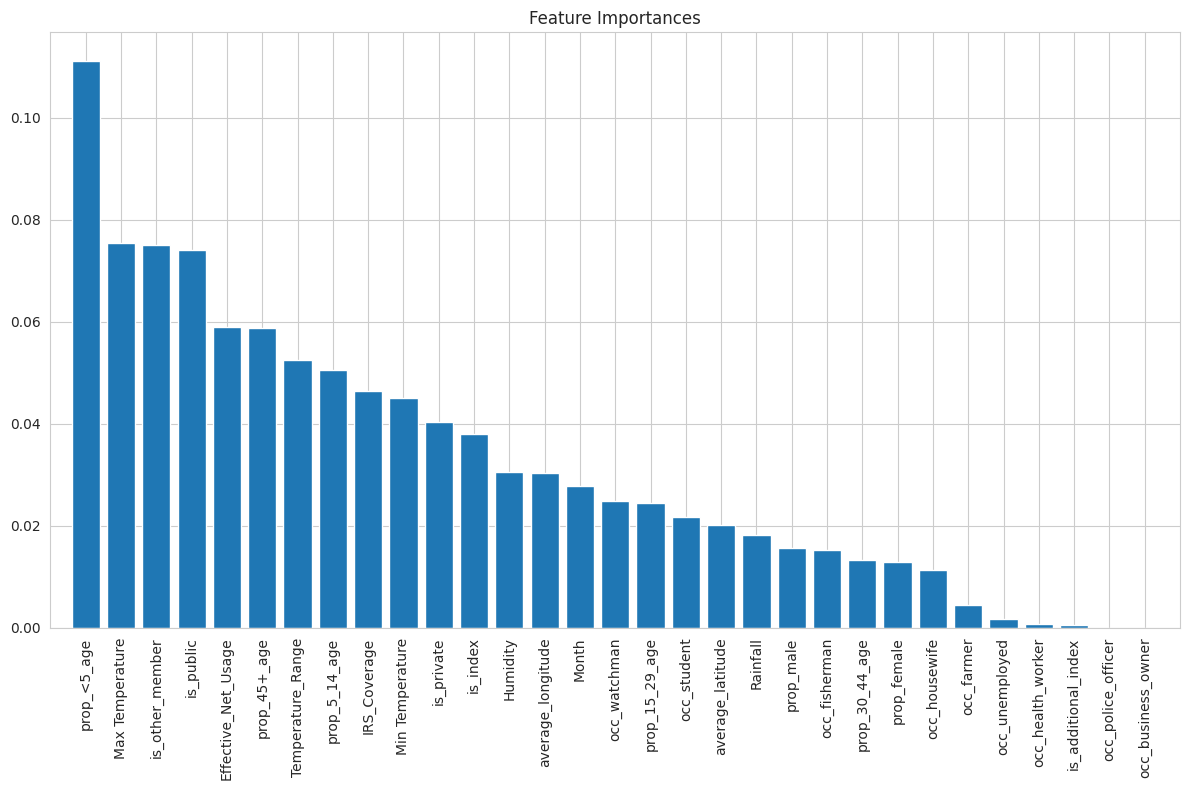

In [14]:
# Get feature importances
importances = rf.feature_importances_
indices = np.argsort(importances)[::-1]

# Plot feature importances
plt.figure(figsize=(12, 8))
plt.title("Feature Importances")
plt.bar(range(X_train.shape[1]), importances[indices], align="center")
plt.xticks(range(X_train.shape[1]), X_train.columns[indices], rotation=90)
plt.xlim([-1, X_train.shape[1]])
plt.tight_layout()
plt.show()

In [15]:
# Define parameter grid
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Initialize GridSearchCV
grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42, class_weight='balanced'),
    param_grid=param_grid,
    cv=5,
    n_jobs=-1,
    scoring='f1'
)

# Fit on training data
grid_search.fit(X_train_res, y_train_res)

# Get best parameters and model
best_params = grid_search.best_params_
best_rf = grid_search.best_estimator_

# Evaluate best model
y_pred_best = best_rf.predict(X_test_scaled)
print("\nBest Model Evaluation:")
print(classification_report(y_test, y_pred_best))
print("\nBest Parameters:", best_params)


Best Model Evaluation:
              precision    recall  f1-score   support

           0       0.99      1.00      1.00      1133
           1       0.00      0.00      0.00        11

    accuracy                           0.99      1144
   macro avg       0.50      0.50      0.50      1144
weighted avg       0.98      0.99      0.99      1144


Best Parameters: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}


/home/tarxemo/venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/tarxemo/venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/tarxemo/venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [16]:
import joblib

# Save the trained model
joblib.dump(best_rf, 'malaria_outbreak_rf_model.pkl')

# Save the scaler
joblib.dump(scaler, 'malaria_scaler.pkl')

# Save the final dataset
combined.to_csv('Final_malaria_prediction_dataset.csv', index=False)

In [17]:
# Create lag features for time series prediction
def create_lag_features(df, features, lags=[1, 2, 3, 4]):
    df = df.sort_values(['District', 'Year', 'Week'])
    for lag in lags:
        for feature in features:
            df[f'{feature}_lag_{lag}'] = df.groupby('District')[feature].shift(lag)
    return df

# Select features to lag
lag_features = [
    'true_malaria_cases', 'Humidity', 'Rainfall', 
    'Min Temperature', 'Max Temperature', 'Effective_Net_Usage', 'IRS_Coverage'
]

# Create lagged dataset
combined_lagged = create_lag_features(combined, lag_features)

# Save for future use
combined_lagged.to_csv('Malaria_prediction_dataset_with_lags.csv', index=False)